In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt

In [17]:
f105w = fits.open("../data/PSFSTD_WFC3IR_F105W.fits")
f125w = fits.open("../data/PSFSTD_WFC3IR_F125W.fits")
f160w = fits.open("../data/PSFSTD_WFC3IR_F160W.fits")

f814w = fits.open("../data/PSFSTD_WFC3UV_F814W.fits", mode='readonly', ignore_missing_end=True)

???????????????????????????????????????????????????????????????????????????????? [astropy.io.fits.card]


# IR filters

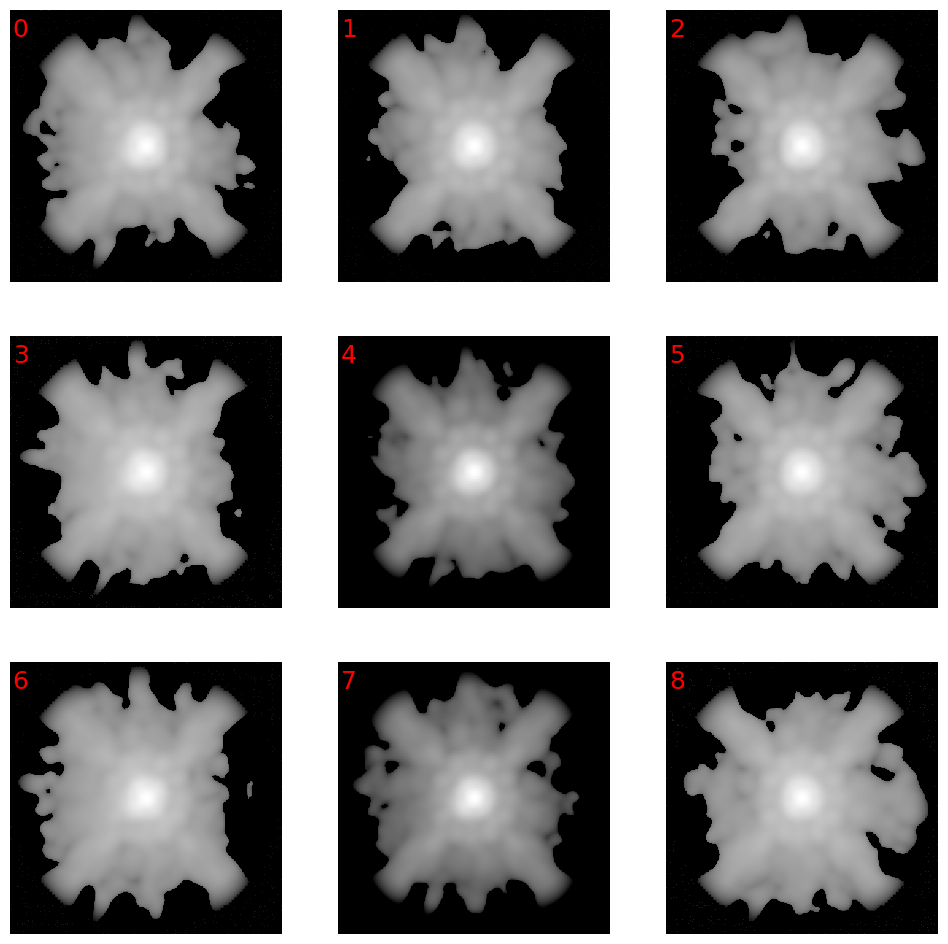

In [30]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    for j in range(3):
        k = i * 3 + j
        axs[i, j].imshow(f105w[0].data[k], cmap="gray", norm=plt.cm.colors.LogNorm(vmin=0, clip=True))
        axs[i, j].annotate(f"{k}", xy=(0.01, 0.9), xycoords="axes fraction", color="r", fontsize=18)
        axs[i, j].axis("off")

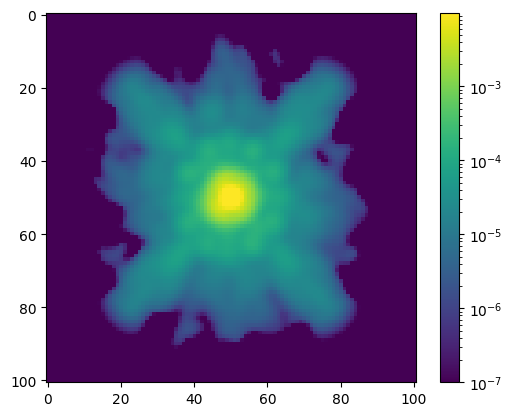

In [73]:
# pick a psf and save it for the forward model
f105psf = f105w[0].data[4]
f105psf[f105psf< 0] = 0.
f105psf /= f105psf.sum()
im = plt.imshow(f105psf, norm=plt.cm.colors.LogNorm(vmin=1e-7, vmax=f814psf.max(), clip=True))
plt.colorbar(im)

In [83]:
hdu = fits.PrimaryHDU(f105psf)
hdu.writeto("../data/F105w_WFC3IR_psf.fits", overwrite=True)

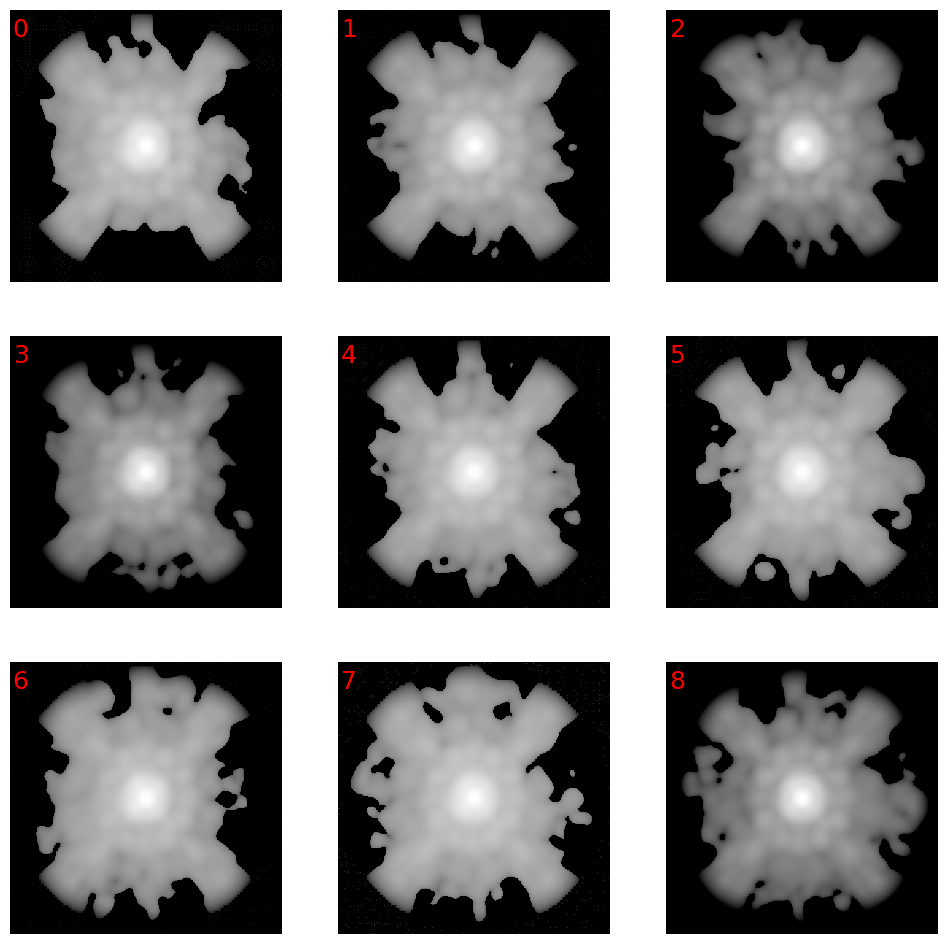

In [29]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    for j in range(3):
        k = i * 3 + j
        axs[i, j].imshow(f125w[0].data[k], cmap="gray", norm=plt.cm.colors.LogNorm(vmin=0, clip=True))
        axs[i, j].annotate(f"{k}", xy=(0.01, 0.9), xycoords="axes fraction", color="r", fontsize=18)
        axs[i, j].axis("off")

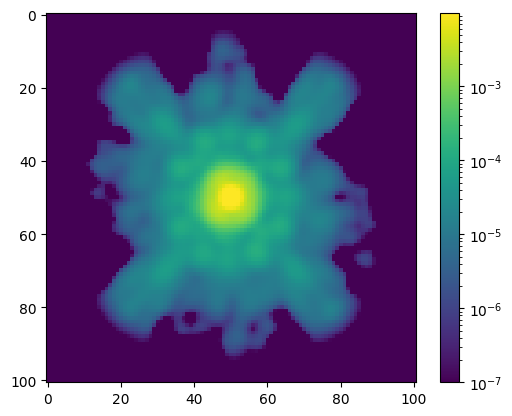

In [75]:
# pick a psf and save it for the forward model
f125psf = f125w[0].data[4]
f125psf[f125psf< 0] = 0.
f125psf /= f125psf.sum()
im = plt.imshow(f125psf, norm=plt.cm.colors.LogNorm(vmin=1e-7, vmax=f814psf.max(), clip=True))
plt.colorbar(im)

In [82]:
hdu = fits.PrimaryHDU(f125psf)
hdu.writeto("../data/F125w_WFC3IR_psf.fits", overwrite=True)

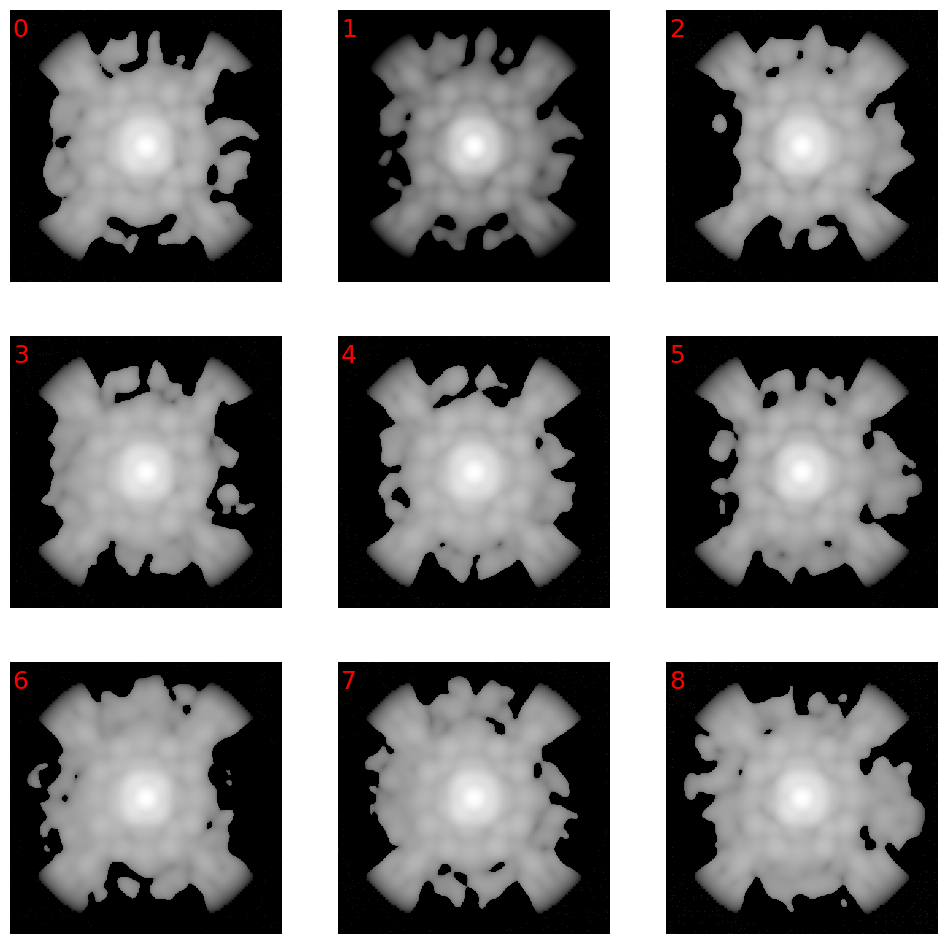

In [28]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    for j in range(3):
        k = i * 3 + j
        axs[i, j].imshow(f160w[0].data[k], cmap="gray", norm=plt.cm.colors.LogNorm(vmin=0, clip=True))
        axs[i, j].annotate(f"{k}", xy=(0.01, 0.9), xycoords="axes fraction", color="r", fontsize=18)
        axs[i, j].axis("off")

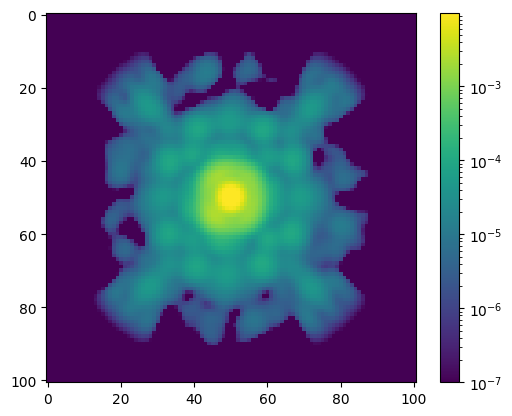

In [77]:
# pick a psf and save it for the forward model
f160psf = f160w[0].data[4]
f160psf[f160psf< 0] = 0.
f160psf /= f160psf.sum()
im = plt.imshow(f160psf, norm=plt.cm.colors.LogNorm(vmin=1e-7, vmax=f814psf.max(), clip=True))
plt.colorbar(im)

In [81]:
hdu = fits.PrimaryHDU(f160psf)
hdu.writeto("../data/F160w_WFC3IR_psf.fits", overwrite=True)

# F814W PSF

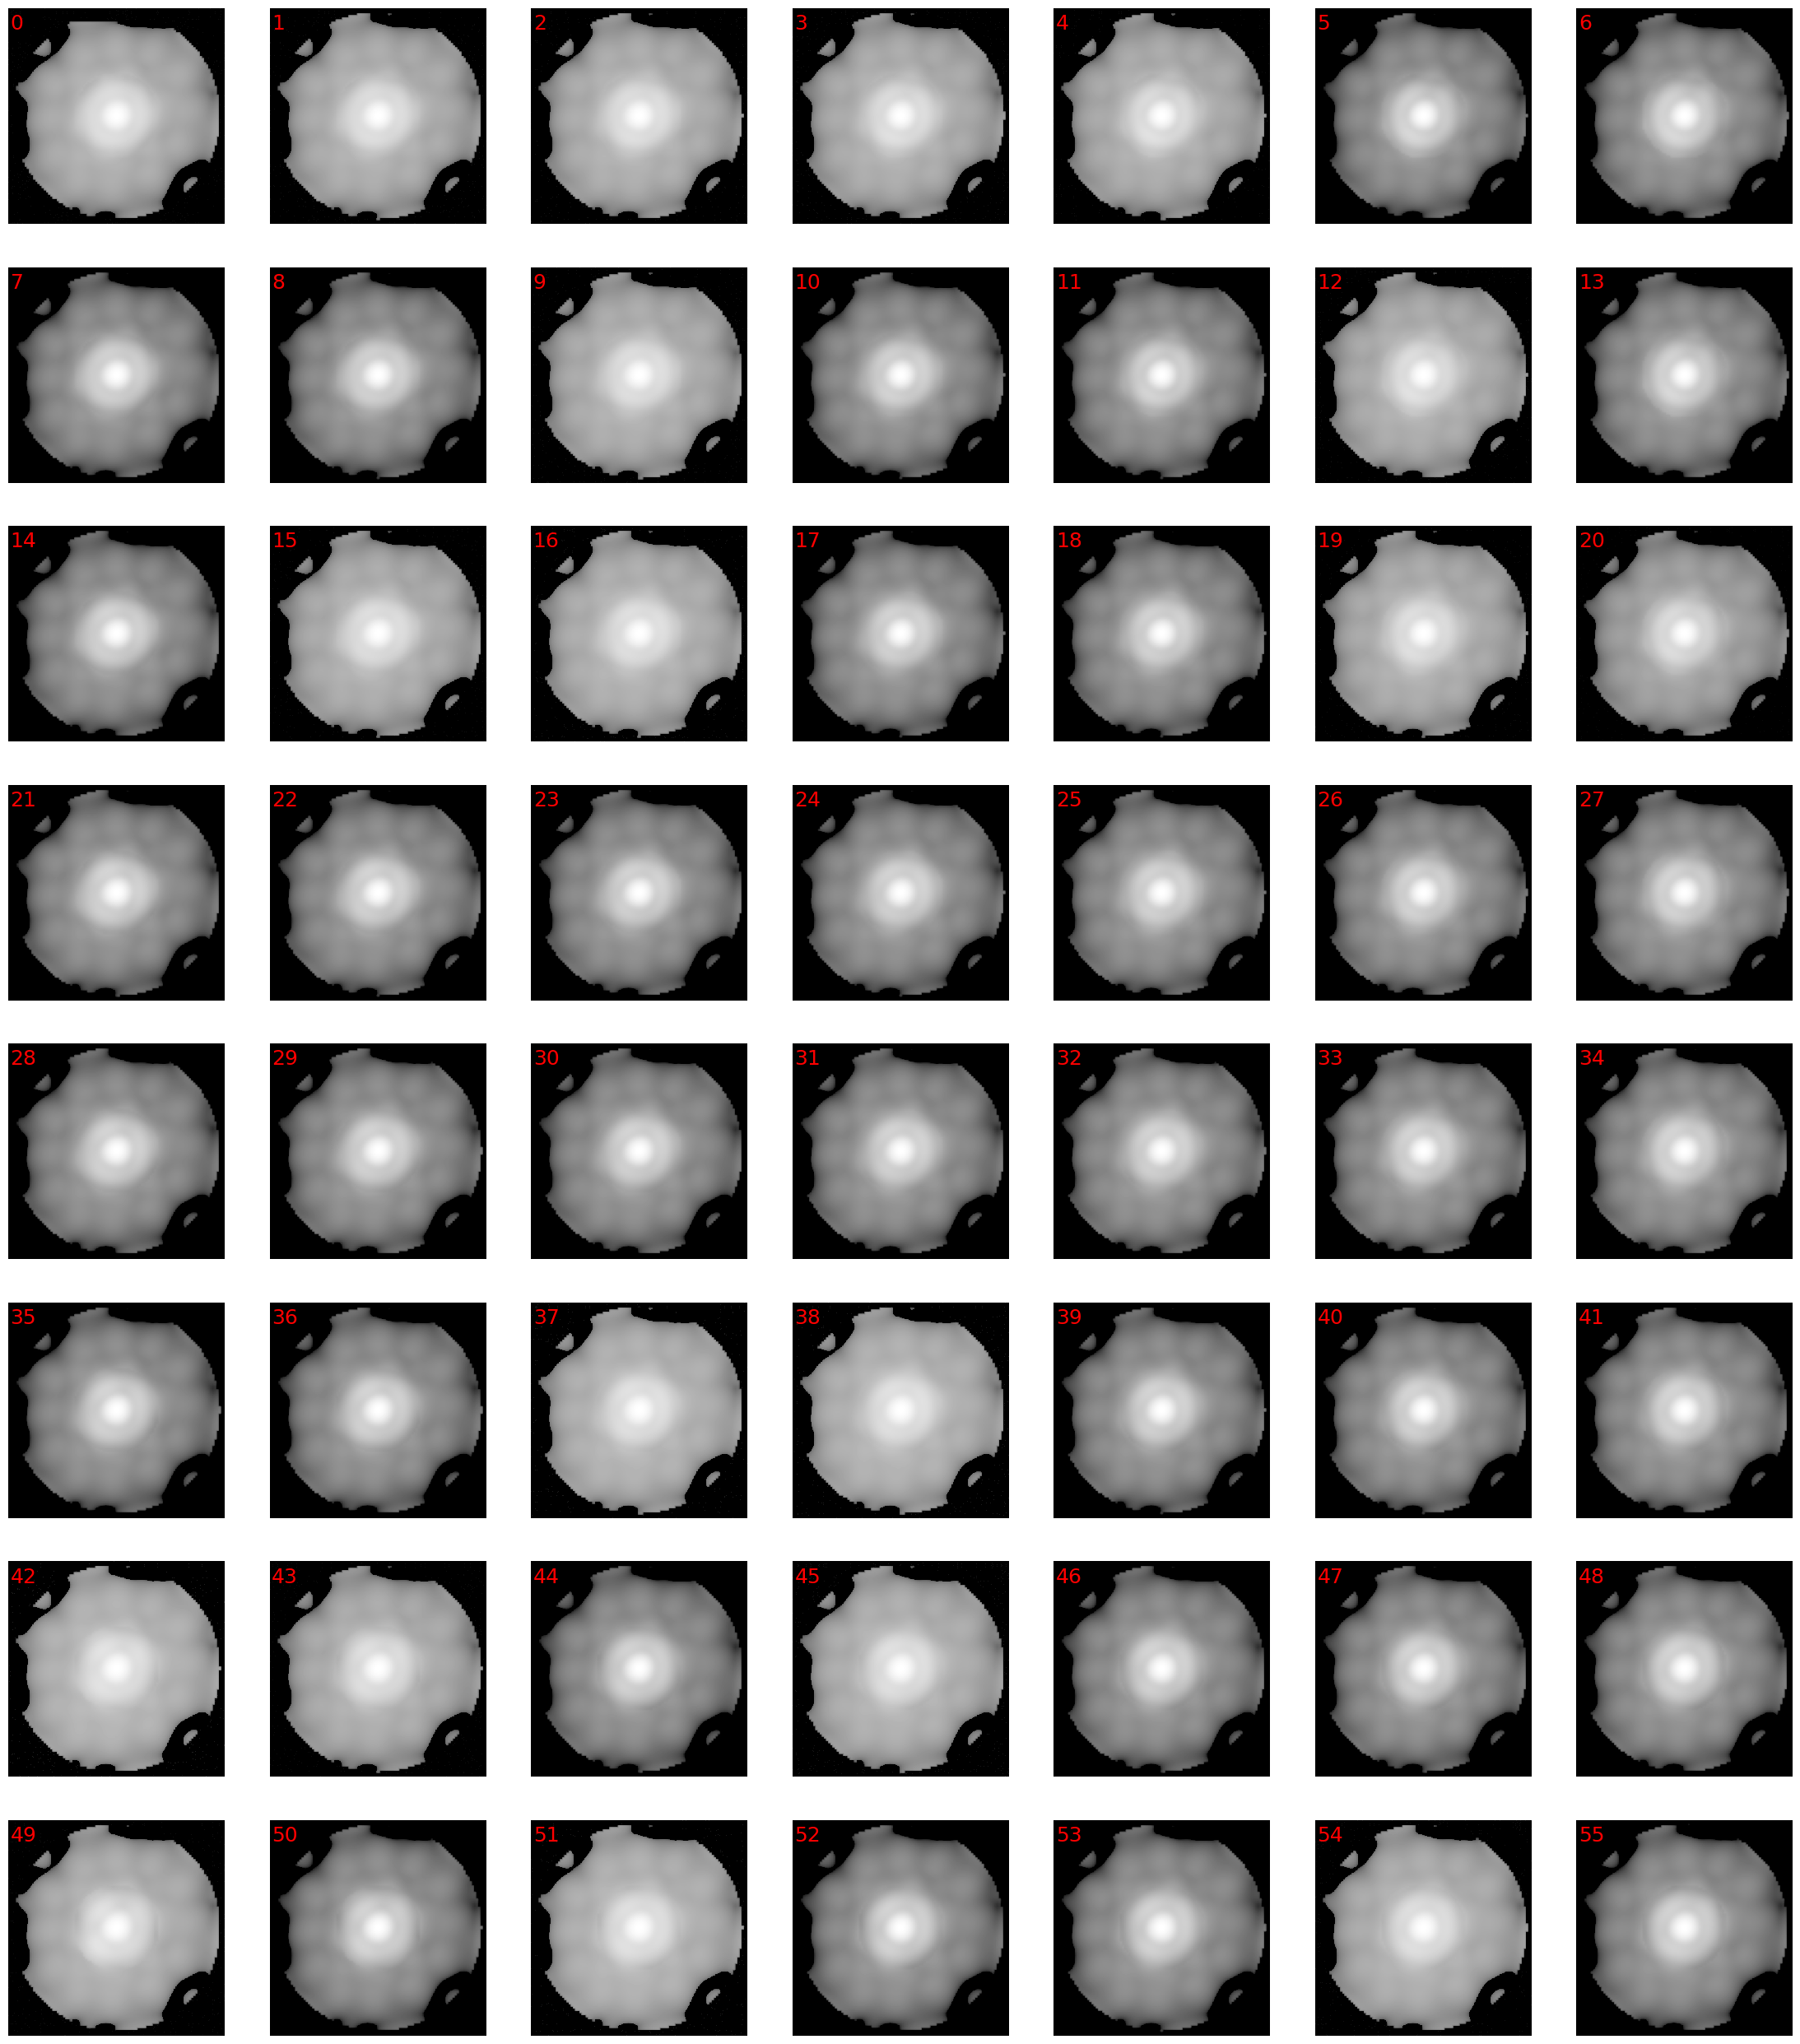

In [27]:
fig, axs = plt.subplots(8, 7, figsize=(7*4, 8*4))
for i in range(8):
    for j in range(7):
        k = i * 7 + j
        axs[i, j].imshow(f814w[0].data[k], cmap="gray", norm=plt.cm.colors.LogNorm(vmin=0, clip=True))
        axs[i, j].annotate(f"{k}", xy=(0.01, 0.9), xycoords="axes fraction", color="r", fontsize=18)
        axs[i, j].axis("off")

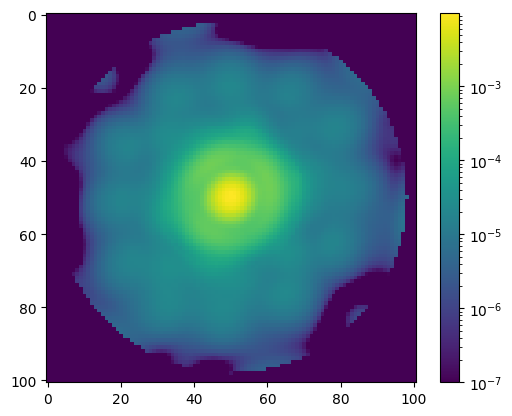

In [54]:
# pick a psf and save it for the forward model
f814psf = f814w[0].data[24]
f814psf[f814psf< 0] = 0.
f814psf /= f814psf.sum()
im = plt.imshow(f814psf, norm=plt.cm.colors.LogNorm(vmin=1e-7, vmax=f814psf.max(), clip=True))
plt.colorbar(im)

In [66]:
hdu = fits.PrimaryHDU(f814psf)
hdu.writeto("../data/F814w_WFC3UV_psf.fits", overwrite=True)

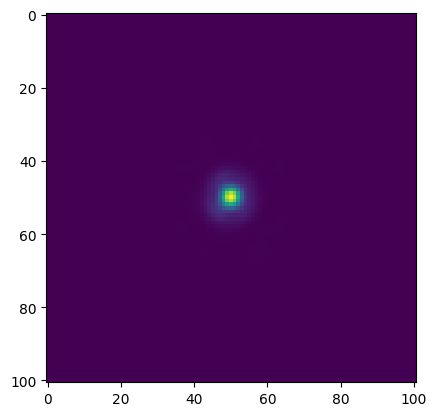

In [85]:
cpsf = fits.open("../data/F125w_WFC3IR_psf.fits")
plt.imshow(cpsf["PRIMARY"].data)